In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
train_data = pd.read_csv('data/train.csv')#Reading the data 
train_data.head()#returns first five rows in the dataset

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


In [4]:
#missing vales check
train_data.isnull().sum()

id                  0
age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64

In [5]:
#Duplicate values check
train_data.duplicated().sum()

np.int64(0)

In [6]:
#check categorical columns
categorical_cols = train_data.select_dtypes(include=['object']).columns.tolist()
print(categorical_cols)

['gender', 'course', 'internet_access', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty']


In [7]:
len(categorical_cols)

7

In [8]:
len(train_data.columns)

13

In [9]:
for col in categorical_cols:
    print(f"{col}:{train_data[col].unique()}")

gender:['female' 'other' 'male']
course:['b.sc' 'diploma' 'bca' 'b.com' 'ba' 'bba' 'b.tech']
internet_access:['no' 'yes']
sleep_quality:['average' 'poor' 'good']
study_method:['online videos' 'self-study' 'coaching' 'group study' 'mixed']
facility_rating:['low' 'medium' 'high']
exam_difficulty:['easy' 'moderate' 'hard']


In [10]:
#Converting categorical cols into numerical cols 
#Label Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
train_data['exam_difficulty_encoded'] = le.fit_transform(train_data['exam_difficulty'])
train_data['facility_rating_encoded'] = le.fit_transform(train_data['facility_rating'])
train_data['internet_access_encoded'] = le.fit_transform(train_data['internet_access'])

train_data.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score,exam_difficulty_encoded,facility_rating_encoded,internet_access_encoded
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3,0,1,0
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7,2,2,1
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0,2,0,1
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9,2,0,1
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0,0,0,1


In [11]:
from sklearn.preprocessing import OneHotEncoder
df_ohe = pd.get_dummies(train_data,columns=['gender','study_method'])
df_ohe.head()

,id,age,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,facility_rating,exam_difficulty,...,facility_rating_encoded,internet_access_encoded,gender_female,gender_male,gender_other,study_method_coaching,study_method_group study,study_method_mixed,study_method_online videos,study_method_self-study
0,0,21,b.sc,7.91,98.8,no,4.9,average,low,easy,...,1,0,True,False,False,False,False,False,True,False
1,1,18,diploma,4.95,94.8,yes,4.7,poor,medium,moderate,...,2,1,False,False,True,False,False,False,False,True
2,2,20,b.sc,4.68,92.6,yes,5.8,poor,high,moderate,...,0,1,True,False,False,True,False,False,False,False
3,3,19,b.sc,2.00,49.5,yes,8.3,average,high,moderate,...,0,1,False,True,False,False,True,False,False,False
4,4,23,bca,7.65,86.9,yes,9.6,good,high,easy,...,0,1,False,True,False,False,False,False,False,True


In [12]:
freq = df_ohe['course'].value_counts()
df_ohe["course_freq"] = df_ohe["course"].map(freq)


In [13]:
df_ohe.isnull().sum()

id                            0
age                           0
course                        0
study_hours                   0
class_attendance              0
internet_access               0
sleep_hours                   0
sleep_quality                 0
facility_rating               0
exam_difficulty               0
exam_score                    0
exam_difficulty_encoded       0
facility_rating_encoded       0
internet_access_encoded       0
gender_female                 0
gender_male                   0
gender_other                  0
study_method_coaching         0
study_method_group study      0
study_method_mixed            0
study_method_online videos    0
study_method_self-study       0
course_freq                   0
dtype: int64

In [14]:
train_data = df_ohe

In [15]:
cols_to_drop = [
    "gender",
    "study_method",
    "course",
    "internet_access",
    "sleep_quality",
    "facility_rating",
    "exam_difficulty"
]

df_ohe = df_ohe.drop(columns=[c for c in cols_to_drop if c in df_ohe.columns])


In [16]:
df_ohe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 18 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   id                          630000 non-null  int64  
 1   age                         630000 non-null  int64  
 2   study_hours                 630000 non-null  float64
 3   class_attendance            630000 non-null  float64
 4   sleep_hours                 630000 non-null  float64
 5   exam_score                  630000 non-null  float64
 6   exam_difficulty_encoded     630000 non-null  int64  
 7   facility_rating_encoded     630000 non-null  int64  
 8   internet_access_encoded     630000 non-null  int64  
 9   gender_female               630000 non-null  bool   
 10  gender_male                 630000 non-null  bool   
 11  gender_other                630000 non-null  bool   
 12  study_method_coaching       630000 non-null  bool   
 13  study_method_g

In [17]:
for col in ["age", "study_hours", "class_attendance", "sleep_hours", "exam_score"]:
    Q1 = df_ohe[col].quantile(0.25)
    Q3 = df_ohe[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df_ohe[col] < lower) | (df_ohe[col] > upper)).sum()
    print(col, "outliers:", count)


age outliers: 0
study_hours outliers: 0
class_attendance outliers: 0
sleep_hours outliers: 0
exam_score outliers: 0


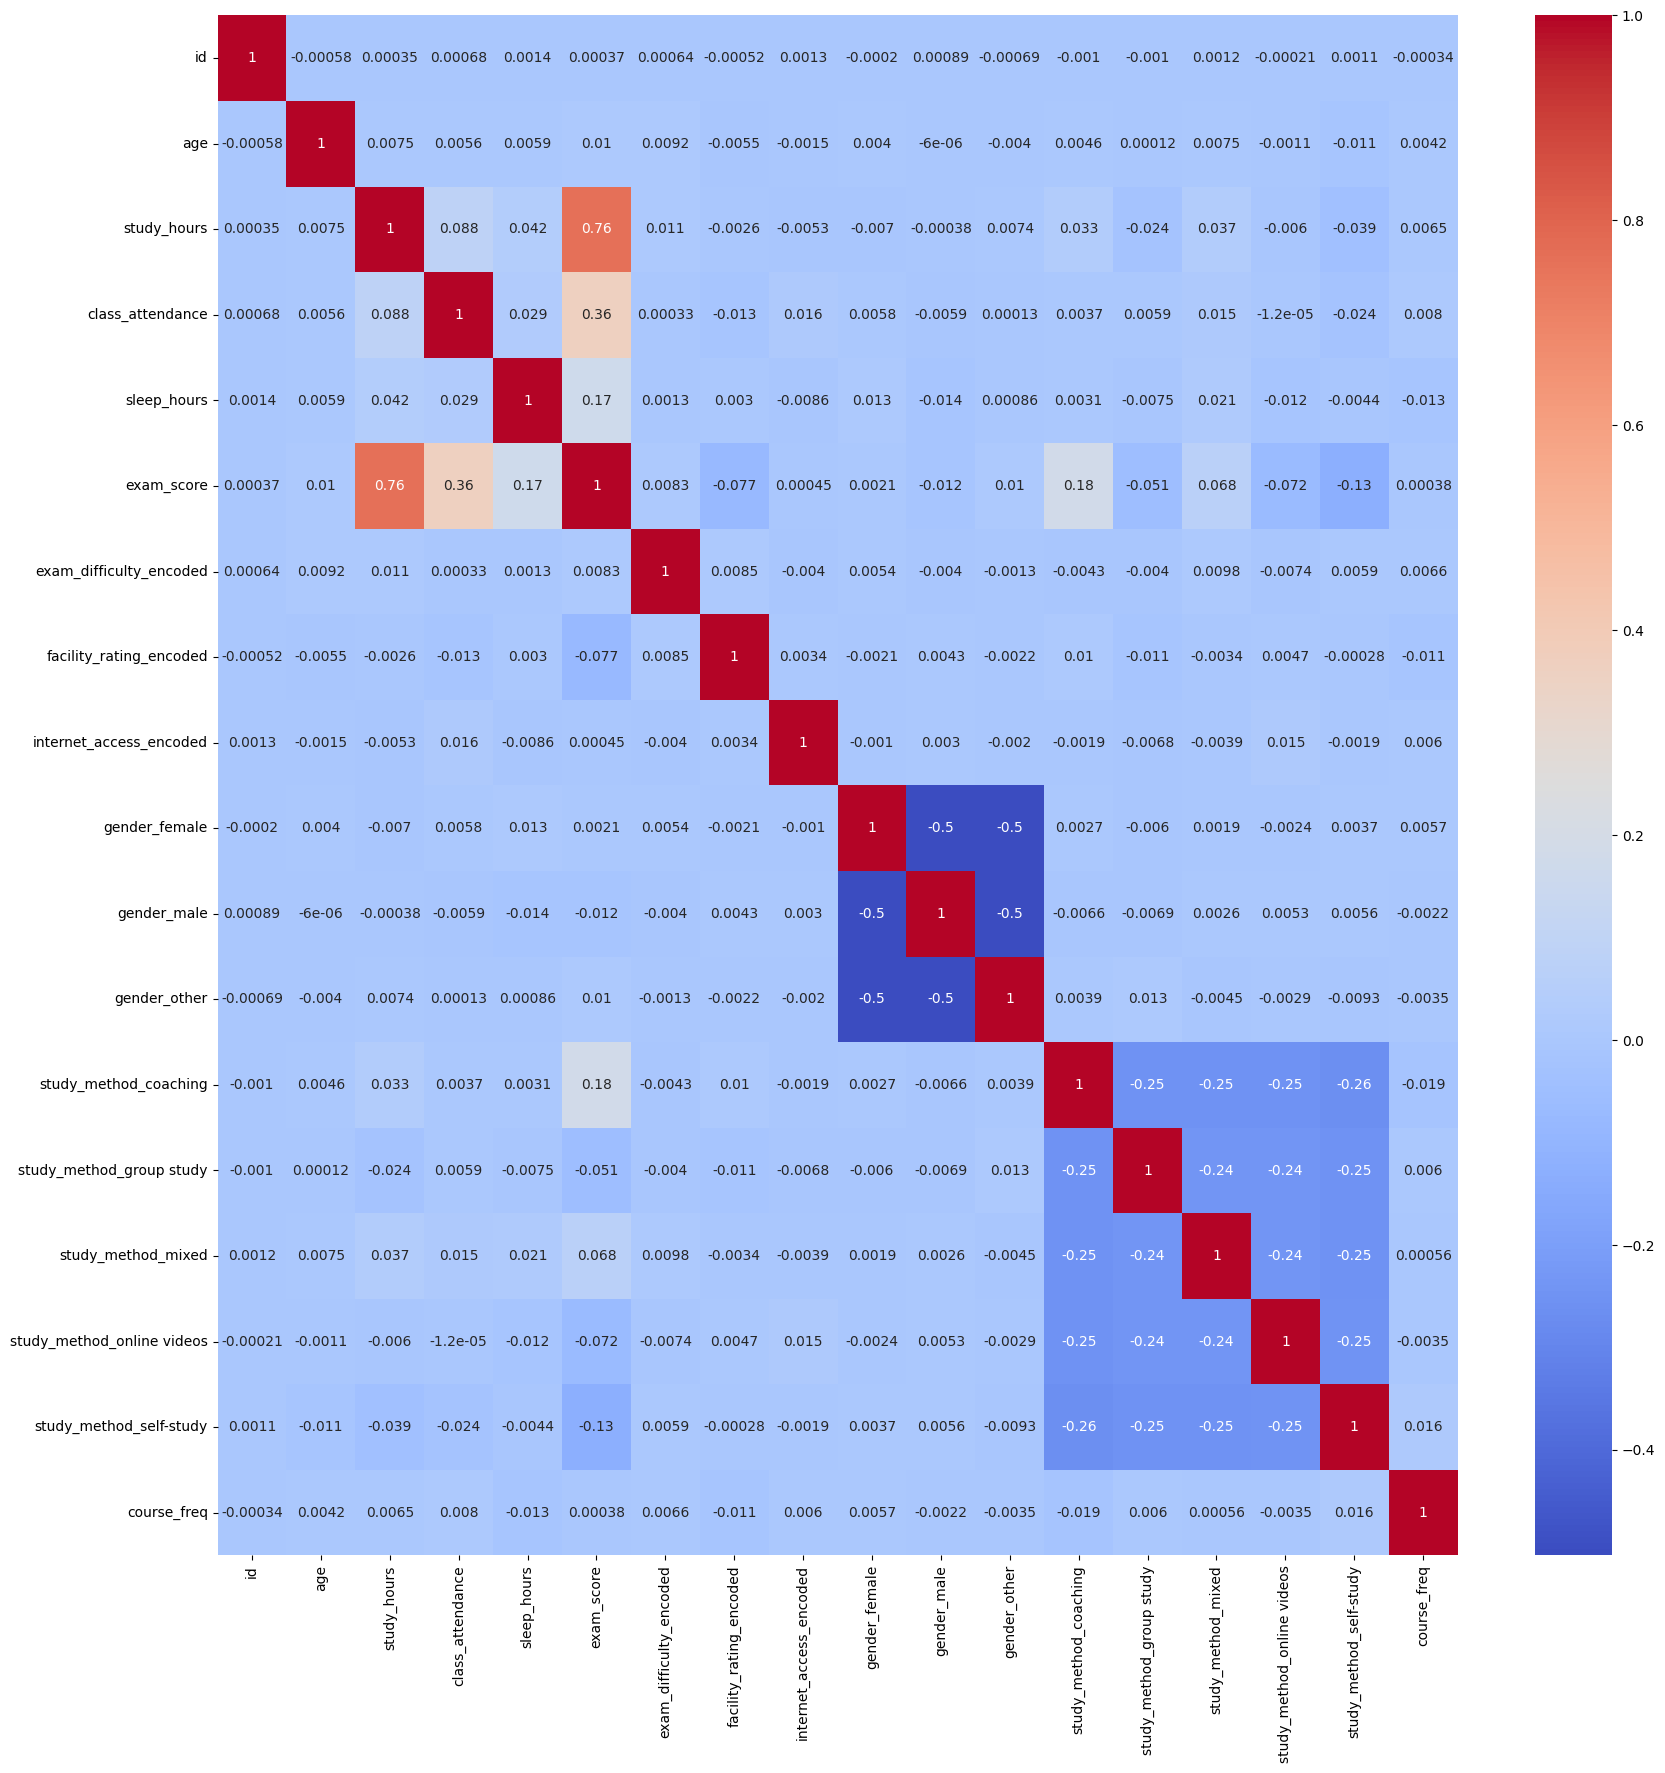

In [21]:
#Correlation matrix

plt.figure(figsize=(20,20))
correlation = df_ohe.corr()

sns.heatmap(correlation,annot=True,cmap='coolwarm')
plt.show()

In [24]:
# As there is train and test data already available i am not doing train test split
X_train =df_ohe.drop(columns=['exam_score'])
y_train = df_ohe['exam_score']


In [25]:
from sklearn.linear_model import LinearRegression

model1 = LinearRegression()
model1.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [26]:
test_df = pd.read_csv('data/test.csv')
test_df.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty
0,630000,24,other,ba,6.85,65.2,yes,5.2,poor,group study,high,easy
1,630001,18,male,diploma,6.61,45.0,no,9.3,poor,coaching,low,easy
2,630002,24,female,b.tech,6.60,98.5,yes,6.2,good,group study,medium,moderate
3,630003,24,male,diploma,3.03,66.3,yes,5.7,average,mixed,medium,moderate
4,630004,20,female,b.tech,2.03,42.4,yes,9.2,average,coaching,low,moderate


In [27]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270000 entries, 0 to 269999
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                270000 non-null  int64  
 1   age               270000 non-null  int64  
 2   gender            270000 non-null  object 
 3   course            270000 non-null  object 
 4   study_hours       270000 non-null  float64
 5   class_attendance  270000 non-null  float64
 6   internet_access   270000 non-null  object 
 7   sleep_hours       270000 non-null  float64
 8   sleep_quality     270000 non-null  object 
 9   study_method      270000 non-null  object 
 10  facility_rating   270000 non-null  object 
 11  exam_difficulty   270000 non-null  object 
dtypes: float64(3), int64(2), object(7)
memory usage: 24.7+ MB


In [28]:
test_ids = test_df["id"]      # save for submission
test_df = test_df.drop(columns=["id"])


In [29]:
# internet_access
test_df["internet_access_encoded"] = test_df["internet_access"].map({
    "no": 0,
    "yes": 1
})

# sleep_quality
test_df["sleep_quality_encoded"] = test_df["sleep_quality"].map({
    "poor": 0,
    "average": 1,
    "good": 2
})

# facility_rating
test_df["facility_rating_encoded"] = test_df["facility_rating"].map({
    "low": 0,
    "medium": 1,
    "high": 2
})

# exam_difficulty
test_df["exam_difficulty_encoded"] = test_df["exam_difficulty"].map({
    "easy": 0,
    "moderate": 1,
    "hard": 2
})


In [30]:
test_df = pd.get_dummies(
    test_df,
    columns=["gender", "study_method"]
)


In [33]:
test_df["course_freq"] = test_df["course"].map(freq)


In [34]:
test_df = test_df.drop(
    columns=[
        "gender",
        "study_method",
        "course",
        "internet_access",
        "sleep_quality",
        "facility_rating",
        "exam_difficulty"
    ],
    errors="ignore"
)


In [35]:
test_df = test_df.reindex(columns=X_train.columns, fill_value=0)


In [37]:
test_predictions = model1.predict(test_df)
print(test_predictions)


[71.42402582 79.46257294 83.42818123 ... 80.40627696 54.79680617
 73.28022471]


In [39]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)


In [40]:
model1.fit(X_tr, y_tr)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [41]:
from sklearn.metrics import mean_absolute_error, r2_score

val_preds = model1.predict(X_val)

print("MAE:", mean_absolute_error(y_val, val_preds))
print("R2:", r2_score(y_val, val_preds))


MAE: 8.00521924905121
R2: 0.7204089924720637


Since mae score is 8 and r^2 is 0.72 we are moving to tree based regression

In [42]:
#RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,        # number of trees
    max_depth=20,           # controls overfitting
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1               # use all CPU cores
)


In [43]:
rf_model.fit(X_tr, y_tr)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

In [44]:
from sklearn.metrics import mean_absolute_error, r2_score

val_preds = rf_model.predict(X_val)

print("RandomForest MAE:", mean_absolute_error(y_val, val_preds))
print("RandomForest R2:", r2_score(y_val, val_preds))


RandomForest MAE: 7.713129213352721
RandomForest R2: 0.7376375601156552


In [46]:
#XGBoost Regressor
from xgboost import XGBRegressor
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)


In [47]:
xgb_model.fit(X_tr, y_tr)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [48]:
from sklearn.metrics import mean_absolute_error, r2_score

val_preds = xgb_model.predict(X_val)

print("XGBoost MAE:", mean_absolute_error(y_val, val_preds))
print("XGBoost R2:", r2_score(y_val, val_preds))


XGBoost MAE: 7.598724047099885
XGBoost R2: 0.746515182458961


In [49]:
xgb_model.fit(X_train, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [50]:
test_predictions = xgb_model.predict(test_df)


In [52]:
submission = pd.DataFrame({
    "id": test_ids,
    "exam_score": test_predictions
})

submission.to_csv("submission.csv", index=False)
